First we do a principal component analysis to reduce the dimension of the bundles data


PCA puis residualisation

In [25]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from neurostatx.io.loader import DatasetLoader
from neurostatx.utils.preprocessing import merge_dataframes
from neurostatx.statistics.models import permutation_testing
from neurostatx. io.viz import generate_coef_plot

from scipy import stats
from statsmodels.regression.linear_model import OLS
from itertools import product

from sklearn.impute import KNNImputer  
from sklearn.metrics import mean_absolute_error, mean_squared_error, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import CCA
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression


In [26]:
# Setting up relevant paths
repository_path = "c:/Users/Rosalie/OneDrive - Office 365/Documents/UdeS/Hiver 2026/Crédits de recherche/GitHub/FuzzyClustering-PING"
data_dir = "c:/Users/Rosalie/OneDrive - Office 365/Documents/UdeS/Hiver 2026/Crédits de recherche/data/"
ping_cfa_dir = "c:/Users/Rosalie/OneDrive - Office 365/Documents/UdeS/Hiver 2026/Crédits de recherche/result/preprocessing/PING_CFA_Apply/"
data_filtered_dir = "c:/Users/Rosalie/OneDrive - Office 365/Documents/UdeS/Hiver 2026/Crédits de recherche/result/PCA/"
output_dir = "c:/Users/Rosalie/OneDrive - Office 365/Documents/UdeS/Hiver 2026/Crédits de recherche/result/PCA/"

# Create output directory if it doesn't exist
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

In [27]:
# Load ping data
ping_cfa = pd.read_excel(f"{ping_cfa_dir}/transformed_dataset.xlsx")

# Load bundles
bundles = pd.read_csv(f"{data_dir}/bundles_mean_stats.tsv", sep='\t')

In [28]:
# Enlever sub- dans la colonne sample du dataset bundles pour faciliter la fusion avec le dataset ping_cfa
bundles['sample'] = bundles['sample'].str.replace('sub-', '', regex=False)

# Convertir en string des deux côtés pour éviter les faux mismatch
ping_cfa["Sample"] = ping_cfa["Sample"].astype(str)
bundles["sample"] = bundles["sample"].astype(str) 

# Filter le dataset ping_cfa pour ne garder que les individus présents dans le dataset bundles
ping_cfa_filtered = ping_cfa[ping_cfa['Sample'].isin(bundles['sample'])].copy()

# Filter le sataset bundles pour ne garder que les individus présents dans le dataset ping_cfa
bundles_filtered = bundles[bundles['sample'].isin(ping_cfa['Sample'])].copy()

ping_cfa_filtered.to_excel(f"{output_dir}/ping_data_filtered_for_bundles.xlsx", index=False, header=True)
bundles_filtered.to_excel(f"{output_dir}/bundles_data_filtered_for_ping.xlsx", index=False, header=True)

In [5]:
# Load ping data
ping_ori = pd.read_excel(f"{data_filtered_dir}/ping_data_filtered_for_bundles.xlsx")

# Load bundles
bundles_ori = pd.read_excel(f"{data_filtered_dir}/bundles_data_filtered_for_ping.xlsx")

In [29]:
# convertir en numérique
measure_cols = bundles_ori.columns[3:]
bundles_ori[measure_cols] = bundles_ori[measure_cols].apply(pd.to_numeric, errors="coerce")
bundles_scaled_tot = bundles_ori.copy()

# Standardiser les donnees des bundles avec mean=0 et std=1 pour les colonnes de mesures
bundles_scaled_tot[measure_cols] = pd.DataFrame(StandardScaler().fit_transform(bundles_ori[measure_cols]))

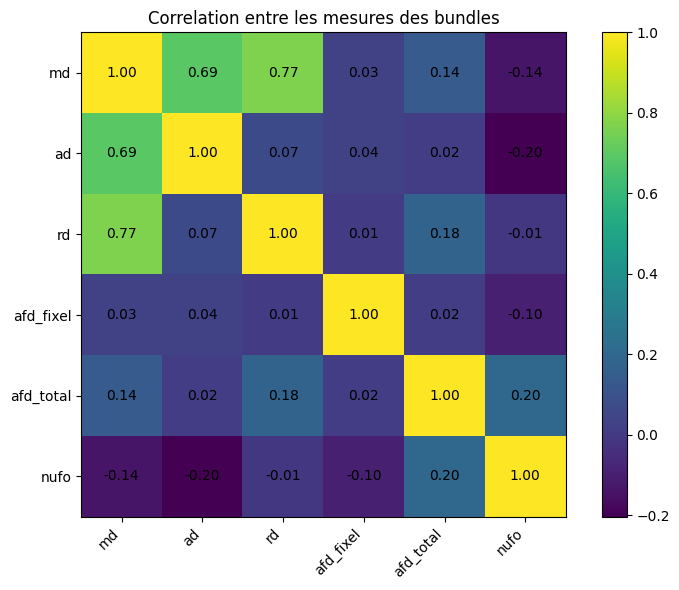

In [30]:
# Matrice de corrélation pour les mesures des bundles
measure_cols = bundles_scaled_tot[["md", "ad", "rd", "afd_fixel", "afd_total", "nufo"]].columns
corr_matrix = bundles_scaled_tot[measure_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr_matrix, interpolation="nearest")
plt.colorbar(im)

ax.set_xticks(range(len(measure_cols)))
ax.set_yticks(range(len(measure_cols)))
ax.set_xticklabels(measure_cols, rotation=45, ha="right")
ax.set_yticklabels(measure_cols)

for i in range(len(measure_cols)):
    for j in range(len(measure_cols)):
        ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}",
                ha="center", va="center")

ax.set_title("Correlation entre les mesures des bundles")
plt.tight_layout()
plt.savefig(f"{output_dir}/corr_bundles_mesures.png", dpi=900)
plt.show()

In [31]:
# Performing PCA 
selected_cols = ["md", "rd", "ad", "nufo", "afd_fixel", "afd_total"]
bundles_scaled = bundles_scaled_tot[["sample", "bundle"] + selected_cols]

pca = PCA()
principal_components = pca.fit_transform(bundles_scaled[selected_cols])
principal_df = pd.DataFrame(data=principal_components, columns=[f"PC{i+1}" for i in range(principal_components.shape[1])])

# Garder les composantes avec eigenvalues >= 1
n_keep = np.sum(pca.explained_variance_ >= 1)
if n_keep == 0:
    n_keep = 1

principal_df = pd.DataFrame(
    data=principal_components[:, :n_keep],
    columns=[f"PC{i+1}" for i in range(n_keep)],
      index=bundles_scaled.index)

# Ajouter les colonnes "sample" et "bundle" au DataFrame des scores PCA
principal_df.insert(0, "sample", bundles_scaled["sample"].values)
principal_df.insert(1, "bundle", bundles_scaled.iloc[:, 1].values)

# variance expliquée
pca_summary = pd.DataFrame({
    "PC": [f"PC{i+1}" for i in range(len(pca.explained_variance_))],
    "Eigenvalue": pca.explained_variance_,
    "Explained_variance_ratio": pca.explained_variance_ratio_,
    "Cumulative_variance": pca.explained_variance_ratio_.cumsum()
})
# loadings
pca_loadings = pd.DataFrame(
    pca.components_.T,
    index=selected_cols,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)]
)

In [32]:
print(pca_summary)

    PC    Eigenvalue  Explained_variance_ratio  Cumulative_variance
0  PC1  2.128718e+00              3.547691e-01             0.354769
1  PC2  1.302375e+00              2.170520e-01             0.571821
2  PC3  1.001879e+00              1.669718e-01             0.738793
3  PC4  8.486506e-01              1.414349e-01             0.880228
4  PC5  7.186685e-01              1.197723e-01             1.000000
5  PC6  1.430396e-11              2.383878e-12             1.000000


In [33]:
print(pca_loadings)

                PC1       PC2       PC3       PC4       PC5           PC6
md         0.679156  0.020891 -0.067675 -0.034635  0.129199  7.182192e-01
rd         0.514109  0.307678  0.018958 -0.607948 -0.011791 -5.205067e-01
ad         0.476828 -0.314318 -0.126627  0.631405  0.214240 -4.617727e-01
nufo      -0.151531  0.646898 -0.033958  0.184157  0.723529  3.156757e-08
afd_fixel  0.051933 -0.203562  0.945601 -0.034388  0.246011  5.478153e-09
afd_total  0.146342  0.588377  0.289330  0.442076 -0.594352  4.492164e-08


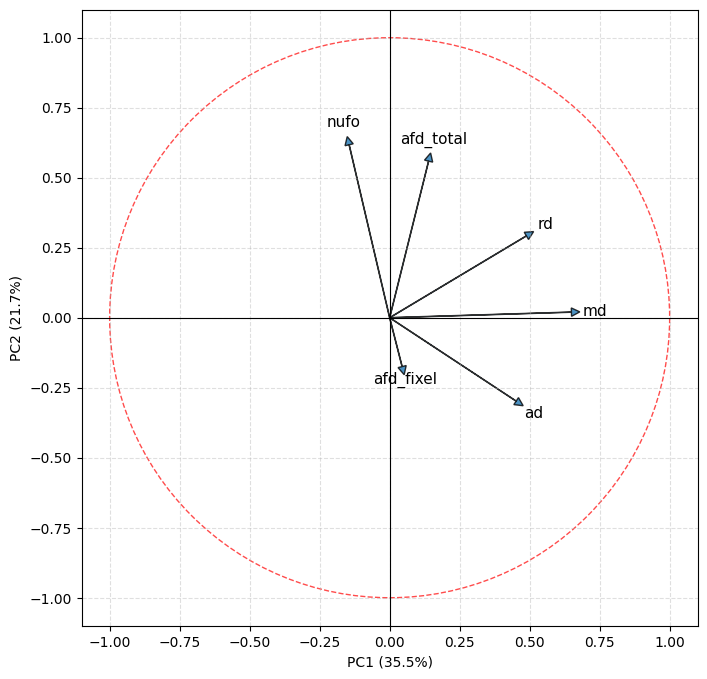

In [34]:
# Extraire les loadings de PC1 et PC2
pc1 = pca_loadings["PC1"]
pc2 = pca_loadings["PC2"]

# Figure
plt.figure(figsize=(8, 8))

# Cercle de corrélation simple
circle = plt.Circle((0, 0), 1, color='red', fill=False, linestyle='--', alpha=0.7)
plt.gca().add_artist(circle)

# Tracer les vecteurs
for var in selected_cols:
    x = pc1[var]
    y = pc2[var]
    
    plt.arrow(
        0, 0, x, y,
        head_width=0.03,
        head_length=0.03,
        length_includes_head=True,
        alpha=0.8
    )
    plt.text(
        x * 1.08,
        y * 1.08,
        var,
        fontsize=11,
        ha='center',
        va='center'
    )

# Axes
plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=0.8)

# Labels avec variance expliquée
var_pc1 = pca.explained_variance_ratio_[0] * 100
var_pc2 = pca.explained_variance_ratio_[1] * 100

plt.xlabel(f"PC1 ({var_pc1:.1f}%)")
plt.ylabel(f"PC2 ({var_pc2:.1f}%)")
plt.title("")
plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)
plt.gca().set_aspect('equal', adjustable='box')
plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout
plt.savefig(f"{output_dir}/loading_plot_PC1_2.png", dpi=900)
plt.show()

In [35]:
# Pivoter et reformuler les lignes et colonnes pour les pc
sample_col = principal_df.columns[0]
bundle_col = principal_df.columns[1]
pc_cols = principal_df.columns[2:]

# pivot : une ligne par sample, colonnes = bundle x pc
bundles_pivot = principal_df.pivot(index=sample_col, columns=bundle_col, values=pc_cols)

In [36]:
# Filtrer les colonnes avec 20% ou plus de valeurs manquantes
missing_pct = bundles_pivot.isna().mean() * 100

vars = ["AF_L", "AF_R", "CC_Fr_1", "CC_Fr_2", "CC_Oc", "CC_Pa", "CC_Pr_Po", "CC_Te",
        "CG_L", "CG_R", "FAT_L", "FAT_R", "FPT_L", "FPT_R", "FX_L", "FX_R", "ICP_L", "ICP_R",
        "IFOF_L", "IFOF_R", "ILF_L", "ILF_R", "MCP", "MdLF_L", "MdLF_R", "OR_ML_L", "OR_ML_R",
        "POPT_L", "POPT_R", "PYT_L", "PYT_R", "SCP_L", "SCP_R", "SLF_L", "SLF_R", "UF_L", "UF_R"]

cols_to_keep = missing_pct[(missing_pct < 20) & (missing_pct.index.get_level_values(1).isin(vars))].index

# colonnes supprimées
cols_removed = bundles_pivot.columns.difference(bundles_20.columns)

bundles_20 = bundles_pivot.loc[:, cols_to_keep].copy()

print("Nombre de colonnes supprimées :", len(cols_removed))
print("Colonnes supprimées :")
print(list(cols_removed))

Nombre de colonnes supprimées : 42
Colonnes supprimées :
[('PC1', 'AC'), ('PC1', 'CG_L_An'), ('PC1', 'CG_L_Po'), ('PC1', 'CG_L_curve'), ('PC1', 'CG_R_An'), ('PC1', 'CG_R_Po'), ('PC1', 'CG_R_curve'), ('PC1', 'FPT_L_Brainstem'), ('PC1', 'FPT_R_Brainstem'), ('PC1', 'PC'), ('PC1', 'POPT_L_Brainstem'), ('PC1', 'POPT_R_Brainstem'), ('PC1', 'PYT_L_Brainstem'), ('PC1', 'PYT_R_Brainstem'), ('PC2', 'AC'), ('PC2', 'CG_L_An'), ('PC2', 'CG_L_Po'), ('PC2', 'CG_L_curve'), ('PC2', 'CG_R_An'), ('PC2', 'CG_R_Po'), ('PC2', 'CG_R_curve'), ('PC2', 'FPT_L_Brainstem'), ('PC2', 'FPT_R_Brainstem'), ('PC2', 'PC'), ('PC2', 'POPT_L_Brainstem'), ('PC2', 'POPT_R_Brainstem'), ('PC2', 'PYT_L_Brainstem'), ('PC2', 'PYT_R_Brainstem'), ('PC3', 'AC'), ('PC3', 'CG_L_An'), ('PC3', 'CG_L_Po'), ('PC3', 'CG_L_curve'), ('PC3', 'CG_R_An'), ('PC3', 'CG_R_Po'), ('PC3', 'CG_R_curve'), ('PC3', 'FPT_L_Brainstem'), ('PC3', 'FPT_R_Brainstem'), ('PC3', 'PC'), ('PC3', 'POPT_L_Brainstem'), ('PC3', 'POPT_R_Brainstem'), ('PC3', 'PYT_L_Brain

In [37]:
# Préparer les mêmes masques pour tous les k
rng = np.random.default_rng(42)

# prendre seulement un sous-ensemble de colonnes pour choisir k
n_test_cols = min(20, bundles_20.shape[1])
test_cols = rng.choice(bundles_20.columns, size=n_test_cols, replace=False)

X_test = bundles_20[test_cols].copy()

# créer un seul plan de masquage
mask_fraction = 0.20
masked_positions = []

X_masked = X_test.copy()

for col in test_cols:
    observed_idx = X_test.index[X_test[col].notna()]
    if len(observed_idx) < 10:
        continue

    n_mask = max(2, int(len(observed_idx) * mask_fraction))
    chosen_idx = rng.choice(observed_idx, size=n_mask, replace=False)

    for idx in chosen_idx:
        masked_positions.append((idx, col))

    X_masked.loc[chosen_idx, col] = np.nan

In [38]:
# tester quelques k 
k_values = [5, 7, 10, 15, 20, 25, 30, 40, 50, 60, 70]
results = []

for k in k_values:
    imputer = KNNImputer(
        n_neighbors=k,
        weights="distance",
        metric="nan_euclidean"
    )

    X_imputed = pd.DataFrame(
        imputer.fit_transform(X_masked),
        index=X_masked.index,
        columns=X_masked.columns
    )

    true_vals = np.array([X_test.loc[idx, col] for idx, col in masked_positions], dtype=float)
    pred_vals = np.array([X_imputed.loc[idx, col] for idx, col in masked_positions], dtype=float)

    rmse = np.sqrt(mean_squared_error(true_vals, pred_vals))
    results.append({"k": k, "rmse": rmse})

results_df = pd.DataFrame(results).sort_values("rmse").reset_index(drop=True)


In [46]:
# Afficher les résultats et choisir le meilleur k
print(results_df[["k", "rmse"]])
best_k = results_df.loc[0, "k"]
print("Best k:", best_k)

     k      rmse
0   25  0.550439
1   20  0.550862
2   15  0.553547
3   30  0.554609
4   40  0.558465
5   50  0.564089
6   10  0.566333
7   60  0.572212
8   70  0.578575
9    7  0.593343
10   5  0.634424
Best k: 25


In [40]:
# Impute the missing values in bundles using the best KNN imputer
imputer = KNNImputer(
    n_neighbors=best_k,
    weights="distance",
    metric="nan_euclidean"
)

bundles_imputed = pd.DataFrame(
    imputer.fit_transform(bundles_20),
    columns=bundles_20.columns,
    index=bundles_20.index
)

In [41]:
# Gerer la colonne/index sample pour le merge
ping_for_merge = ping_ori.copy()
ping_for_merge = ping_for_merge.rename(columns={"Sample": "sample"})
ping_for_merge["sample"] = ping_for_merge["sample"].astype(str)

bundles_for_merge = bundles_imputed.reset_index()
bundles_for_merge["sample"] = bundles_for_merge["sample"].astype(str)

# Verifier l'ordre des samples
(ping_for_merge["sample"].values == bundles_for_merge["sample"].values).all()

np.True_

In [42]:
# Merge
ping_and_bundles = merge_dataframes({"ping" : ping_for_merge, "bundles" : bundles_for_merge}, index="sample")

In [43]:
# Residualisation des bundles pour age, sex, handedness, etchnicity
# Separate the covariates and the variates data
covars = ping_and_bundles[["Sex", "AgeMonths", "Ethnicity", "Handedness"]].copy()
vars = ping_and_bundles.iloc[:, 15:].copy()

covars = sm.add_constant(covars)

# Store residuals in a dict first
residuals_dict = {}

# Running a linear regression model for each variate
for var in vars.columns:
    model = OLS(vars[var], covars)
    results = model.fit()
    residuals_dict[var] = results.resid

# Build the dataframe once
residuals = pd.DataFrame(residuals_dict, index=ping_and_bundles.index)

# Instantiating an empty dataframe to store the results
#residuals = pd.DataFrame(index=ping_and_bundles.index)

# Running a linear regression model for eact variate
#for var in vars.columns:
  #  model = OLS(vars[var], covars)
   # results = model.fit()
   # residuals[var] = results.resid

In [44]:
# Merging the residuals with the original data
ping_bundles_resid = pd.concat([ping_and_bundles.drop(columns=vars), residuals], axis=1)

# Saving the residualized data.
ping_bundles_resid.to_excel(f"{output_dir}/ping_bundles_residualized.xlsx", index=True, header=True)

In [45]:
# Verifier que la residiualisation a bien fonctionné
X = sm.add_constant(ping_and_bundles[["AgeMonths", "Sex", "Ethnicity", "Handedness"]])

for col in residuals.columns:
    model = sm.OLS(residuals[col], X).fit()
    print(f"\n{col}")
    print(model.summary().tables[1])
# Coef environ 0 = pas de relation entre les covariables et les variables d'intérêt, ce qui est le but de la residualisation.
# P values élevés (1) = pas de relation significative entre les covariables et les variables d'intérêt, ce qui est également le but de la residualisation.


('PC1', 'AF_L')
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -3.214e-16      0.259  -1.24e-15      1.000      -0.510       0.510
AgeMonths   9.625e-16      0.001   1.09e-12      1.000      -0.002       0.002
Sex         8.552e-16      0.077   1.12e-14      1.000      -0.150       0.150
Ethnicity  -1.761e-16      0.023  -7.66e-15      1.000      -0.045       0.045
Handedness  3.326e-16      0.101   3.28e-15      1.000      -0.199       0.199

('PC1', 'AF_R')
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -3.873e-16      0.262  -1.48e-15      1.000      -0.514       0.514
AgeMonths   1.012e-15      0.001   1.13e-12      1.000      -0.002       0.002
Sex         1.018e-15      0.077   1.32e-14      1.000      -0.152       0.152
Ethnicity  -1.752e